# Etapa 00. ¿Qué sistema muestran nuestros datos?


Una primera reunión suele comenzar con cifras: generación anual, demanda máxima, precio medio. Antes de buscar una gran explicación, necesitamos asegurarnos de que las cifras representan lo que creemos. El trabajo profesional empieza aquí porque una unidad equivocada puede convertir un año de producción en una supuesta capacidad y construir después una historia falsa de déficit.

Abrimos el registro diario con 24 valores de energía. Sumarlos produce energía diaria; promediarlos respondería otra pregunta. Al sumar el año obtenemos GWh. Dividir por las horas efectivas del calendario y convertir unidades da potencia media, no capacidad efectiva. El máximo diario de demanda viene en kW: se divide por mil y luego se toma el máximo anual. Estas operaciones parecen pequeñas; sostienen toda la interpretación posterior.

La comparación generación–demanda comercial es descriptiva. No la llamamos reserva ni atribuimos su diferencia a un único flujo sin conciliar fronteras. También examinamos 2025: un archivo disponible puede terminar antes de diciembre. Si queremos comparar años completos, excluimos ese período sin fingir que está completo o proyectarlo silenciosamente.

Después miramos el perfil horario promedio de 2024. El promedio conserva una forma diaria y oculta diferencias entre días. Precio medio y precio ponderado por demanda contestan preguntas distintas. El segundo usa energía como peso; no es tarifa del usuario ni precio capturado por una planta solar. Anota qué magnitud necesitarías para cada una de esas preguntas.

La mirada convencional aporta aquí aritmética, calidad de datos y descripción. La perspectiva sistémica pregunta qué dependencias y escalas se esconden detrás del agregado. Todavía no hay evidencia de causalidad ni una propuesta de expansión. El primer entregable es una radiografía que otro analista pueda reconstruir y una pregunta que esa radiografía haga pertinente.

**Discusión acompañada:** si el promedio anual de potencia aumenta y el pico también, no sabemos aún si cambia la forma de la curva de carga. El perfil horario agrega otra dimensión. Si quisiéramos estudiar suficiencia, faltarían disponibilidad y demanda coincidentes en condiciones críticas. El resultado observado conduce así a una solicitud precisa, no a una conclusión de racionamiento.

**Entrega:** dos hallazgos descriptivos, una transformación explicada a mano, cobertura temporal y una pregunta sectorial. Para cada hallazgo escribe una frase que sí respalde el dato y otra que sería un exceso de interpretación.


# Etapa 00 — ¿Qué sistema muestran nuestros datos?

Consulta el dossier. Predice, calcula, explica y juzga el alcance antes de registrar tu decisión.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
# Encuentra la raíz tanto desde la carpeta del notebook como desde la raíz del libro.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'sa_mise' / '__init__.py').exists())
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from sa_mise import datos, modelos, expediente
plt.rcParams.update({'figure.figsize': (10, 4), 'axes.grid': True, 'grid.alpha': .2})

In [2]:
from sa_mise import sector
CASO='ejemplo_docente'
# Usa el mismo identificador de tu equipo en las ocho etapas.

## 1. Las unidades antes de la historia
Comprobamos cobertura y calculamos energía, potencia media y pico con sus operaciones respectivas. Revisa 2025 en la primera tabla y explica por qué no se mezcla con años completos.

In [3]:
display(datos.cobertura(datos.leer_diario('xm_generacion_raw.csv')).tail())
balance=datos.balance_descriptivo();display(balance.tail())
ultimo=balance.iloc[-1]
print('Último año completo:',int(ultimo.anio),'Generación GWh:',ultimo.generacion_GWh,'Pico MW:',ultimo.demanda_pico_MW)

Último año completo: 2024 Generación GWh: 83262.92316385 Pico MW: 11704.365


,anio,dias_observados,dias_calendario,completo,inicio,fin
21,2021,365,365,True,2021-01-01,2021-12-31
22,2022,365,365,True,2022-01-01,2022-12-31
23,2023,365,365,True,2023-01-01,2023-12-31
24,2024,366,366,True,2024-01-01,2024-12-31
25,2025,243,365,False,2025-01-01,2025-08-31


,anio,generacion_GWh,dias,horas,potencia_media_MW,demanda_comercial_GWh,diferencia_contable_GWh,demanda_pico_MW
10,2020,69323.556076,366,8784,7892.025965,70625.145471,-1301.589395,10538.876
11,2021,73933.548796,365,8760,8439.902831,74412.780033,-479.231237,10814.564
12,2022,76908.449073,365,8760,8779.503319,77067.600303,-159.151230,10893.881
13,2023,80684.236454,365,8760,9210.529276,81214.325212,-530.088758,11475.237
14,2024,83262.923164,366,8784,9478.930233,83308.047753,-45.124589,11704.365


La tabla distingue energía y potencia. No leas la diferencia contable como reserva. El pico es una observación anual, no una medida de capacidad firme disponible. Escribe un hallazgo limitado a lo que muestra cada columna.

## 2. El promedio también tiene un perfil
Cada valor horario de energía se divide por una hora y por mil para obtener MW medios en ese intervalo. Comparamos horas del día, preservando el año completo.

{'dias': 366,
 'precio_medio_nominal_COP_kWh': 676.0761965209472,
 'precio_ponderado_demanda_comercial_COP_kWh': 686.1925651090507}

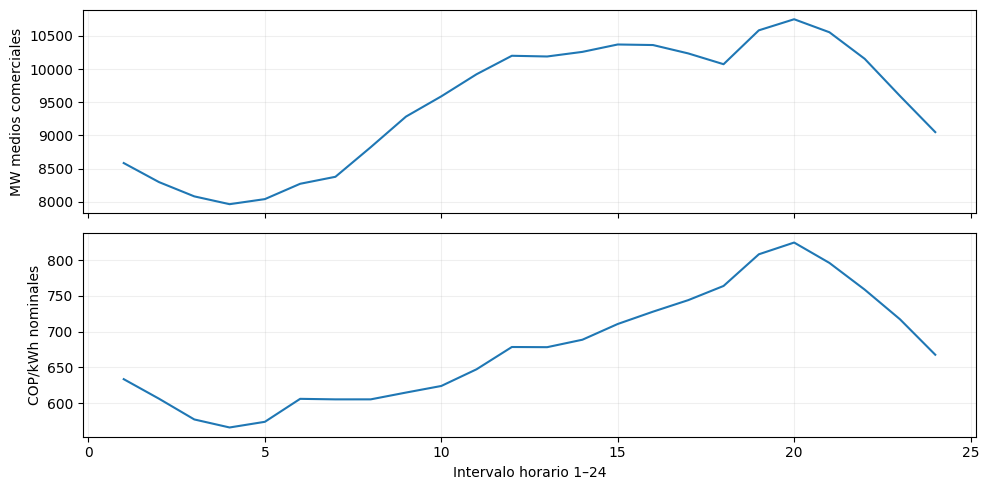

In [4]:
perfil,indicadores=sector.perfiles_horarios();display(indicadores)
fig,axs=plt.subplots(2,1,figsize=(10,5),sharex=True)
axs[0].plot(perfil.hora_intervalo,perfil.potencia_media_demanda_comercial_MW);axs[0].set_ylabel('MW medios comerciales')
axs[1].plot(perfil.hora_intervalo,perfil.precio_medio_nominal_COP_kWh);axs[1].set_ylabel('COP/kWh nominales');axs[1].set_xlabel('Intervalo horario 1–24')
plt.tight_layout();plt.show()

Cada punto promedia muchos días. No muestra máximos ni una jornada específica. Los precios ponderados por energía responden al perfil de demanda comercial y no al perfil de una planta. Para evaluar suficiencia hay que volver a simultaneidad y disponibilidad.

## Registrar el avance del equipo
Sustituye el campo de decisión por tu razonamiento y conserva el nivel de evidencia. El identificador es el mismo durante todo el caso.

In [5]:
decision_estudiante='POR COMPLETAR'
expediente.registrar(CASO,'evidencia',f'Año {int(ultimo.anio)}: generación {ultimo.generacion_GWh:.3f} GWh y pico {ultimo.demanda_pico_MW:.3f} MW; son magnitudes diferentes','descripcion' if 0 in [0,1] else 'exploracion',
 'Extractos locales y/o supuestos identificados en DOSSIER y esta etapa',
 'Transformaciones, calendario y unidades explícitos en las celdas precedentes',
 'No constituye evaluación completa del SIN; distinguir cada resultado observado de los sintéticos',
 decision_estudiante)

Out[5]: 
{'version': 2,
 'caso': 'ejemplo_docente',
 'etapas': {'evidencia': {'hallazgo': 'Año 2024: generación 83262.923 GWh y pico 11704.365 MW; son magnitudes diferentes',
   'nivel': 'descripcion',
   'fuente': 'Extractos locales y/o supuestos identificados en DOSSIER y esta etapa',
   'transformacion': 'Transformaciones, calendario y unidades explícitos en las celdas precedentes',
   'limite': 'No constituye evaluación completa del SIN; distinguir cada resultado observado de los sintéticos',
   'decision_estudiante': 'POR COMPLETAR'},
  'identidad': {'hallazgo': "Asociaciones mensuales: {'meses': 264, 'correlacion_bruta': -0.3654022452929349, 'correlacion_residual': -0.5459860648178948, 'interpretacion': 'Asociación; controles aditivos no identifican causalidad ni corrigen toda no estacionariedad'}",
   'nivel': 'descripcion',
   'fuente': 'Extractos locales y/o supuestos identificados en DOSSIER y esta etapa',
   'transformacion': 'Transformaciones, calendario y unidades explícit